Columns in dataset: ['url', 'method', 'param_name', 'input_type', 'default_value', 'form_action']
✅ Features extracted and saved to features_extracted.csv


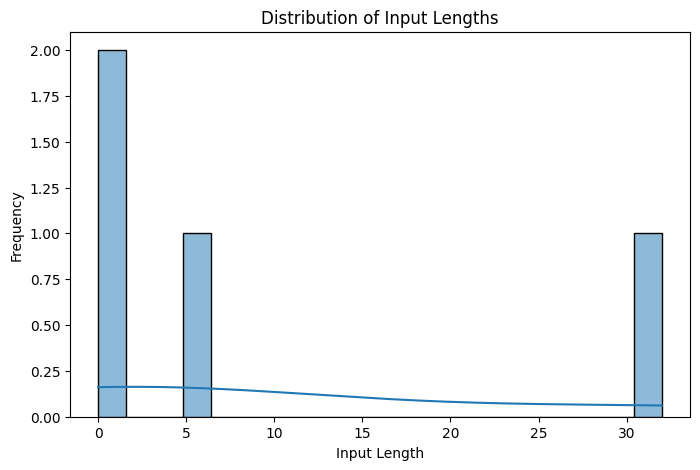

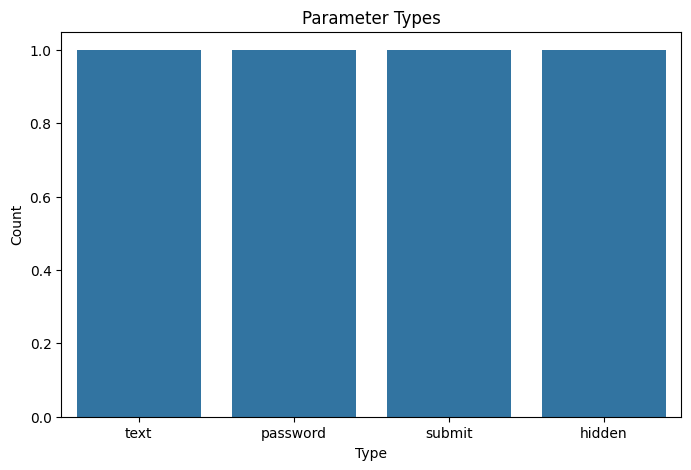

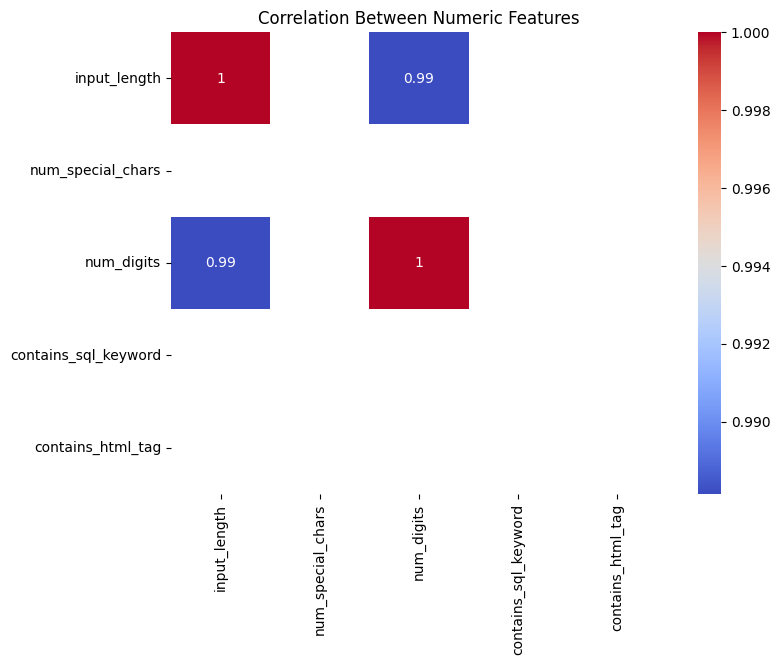

In [2]:
# feature_extraction.ipynb

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ---------------- LOAD DATA ----------------
INPUT_FILE = "metadata.csv"  # or features_extracted.csv if already processed
df = pd.read_csv(INPUT_FILE)
print("Columns in dataset:", df.columns.tolist())

# ---------------- HELPER FUNCTIONS ----------------
def count_special_chars(s):
    if pd.isna(s):
        return 0
    return sum(1 for c in str(s) if c in "<>'\"%&;()")

def count_digits(s):
    if pd.isna(s):
        return 0
    return sum(c.isdigit() for c in str(s))

def is_alpha_only(s):
    if pd.isna(s) or len(s) == 0:
        return False
    return str(s).isalpha()

def contains_sql_keyword(s):
    if pd.isna(s):
        return 0
    sql_keywords = ["SELECT", "INSERT", "UPDATE", "DELETE", "UNION", "DROP", "WHERE", "OR", "AND"]
    s_upper = str(s).upper()
    return int(any(keyword in s_upper for keyword in sql_keywords))

def contains_html_tag(s):
    if pd.isna(s):
        return 0
    return int(bool(re.search(r"<(script|img|iframe|div|a|form)", str(s), re.IGNORECASE)))

# ---------------- FEATURE EXTRACTION ----------------
df["input_value"] = df["default_value"].fillna("") if "default_value" in df.columns else ""
df["input_length"] = df["input_value"].apply(len)
df["num_special_chars"] = df["input_value"].apply(count_special_chars)
df["num_digits"] = df["input_value"].apply(count_digits)
df["is_alpha_only"] = df["input_value"].apply(is_alpha_only)
df["param_type"] = df["input_type"] if "input_type" in df.columns else "text"
df["contains_sql_keyword"] = df["input_value"].apply(contains_sql_keyword)
df["contains_html_tag"] = df["input_value"].apply(contains_html_tag)

# ---------------- SAVE FEATURE CSV ----------------
feature_cols = [
    "url",
    "param_name",
    "input_value",
    "input_length",
    "num_special_chars",
    "num_digits",
    "is_alpha_only",
    "param_type",
    "contains_sql_keyword",
    "contains_html_tag"
]

# Keep only existing columns
feature_cols_existing = [col for col in feature_cols if col in df.columns]

df[feature_cols_existing].to_csv("features_extracted.csv", index=False)
print(f"✅ Features extracted and saved to features_extracted.csv")

# ---------------- VISUALIZATION ----------------

# Histogram of input lengths
if "input_length" in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df["input_length"], bins=20, kde=True)
    plt.title("Distribution of Input Lengths")
    plt.xlabel("Input Length")
    plt.ylabel("Frequency")
    plt.show()

# Bar chart of parameter types
if "param_type" in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x="param_type")
    plt.title("Parameter Types")
    plt.xlabel("Type")
    plt.ylabel("Count")
    plt.show()

# Correlation heatmap of numeric features
numeric_cols = [col for col in ["input_length", "num_special_chars", "num_digits", "contains_sql_keyword", "contains_html_tag"] if col in df.columns]

if numeric_cols:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Between Numeric Features")
    plt.show()
